In [1]:
import pandas as pd

# Update the path based on where you saved it
df = pd.read_csv("C:/Projects/SmartCityTraffic/Metro_Interstate_Traffic_Volume.csv")

df.head()


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [2]:
# Check the shape of data
print("Rows, Columns:", df.shape)

# Check missing values
print(df.isnull().sum())

# Check data types
print(df.dtypes)


Rows, Columns: (48204, 9)
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64
holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object


In [4]:
# Convert date_time to datetime type
df['date_time'] = pd.to_datetime(df['date_time'])

# Fill missing holidays with 'None'
df['holiday'].fillna('None', inplace=True)

# Verify changes
print(df.dtypes)
print(df['holiday'].value_counts().head())


holiday                        object
temp                          float64
rain_1h                       float64
snow_1h                       float64
clouds_all                      int64
weather_main                   object
weather_description            object
date_time              datetime64[ns]
traffic_volume                  int64
dtype: object
holiday
Washingtons Birthday    13342
Independence Day         6938
Memorial Day             5478
Labor Day                4391
Thanksgiving Day         4236
Name: count, dtype: int64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25268\169517206.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['holiday'].fillna('None', inplace=True)


In [5]:
df['holiday'].fillna('None', inplace=True)


In [6]:
df['holiday'] = df['holiday'].fillna('None')


               temp       rain_1h       snow_1h    clouds_all  \
count  48187.000000  48187.000000  48187.000000  48187.000000   
mean     281.204995      0.334382      0.000222     49.365451   
min        0.000000      0.000000      0.000000      0.000000   
25%      272.160000      0.000000      0.000000      1.000000   
50%      282.450000      0.000000      0.000000     64.000000   
75%      291.806000      0.000000      0.000000     90.000000   
max      310.070000   9831.300000      0.510000    100.000000   
std       13.338738     44.797033      0.008169     39.015213   

                           date_time  traffic_volume  
count                          48187    48187.000000  
mean   2016-01-05 06:49:48.133729024     3259.618134  
min              2012-10-02 09:00:00        0.000000  
25%              2014-02-06 07:30:00     1192.500000  
50%              2016-06-10 21:00:00     3379.000000  
75%              2017-08-11 05:30:00     4933.000000  
max              2018-09-30 2

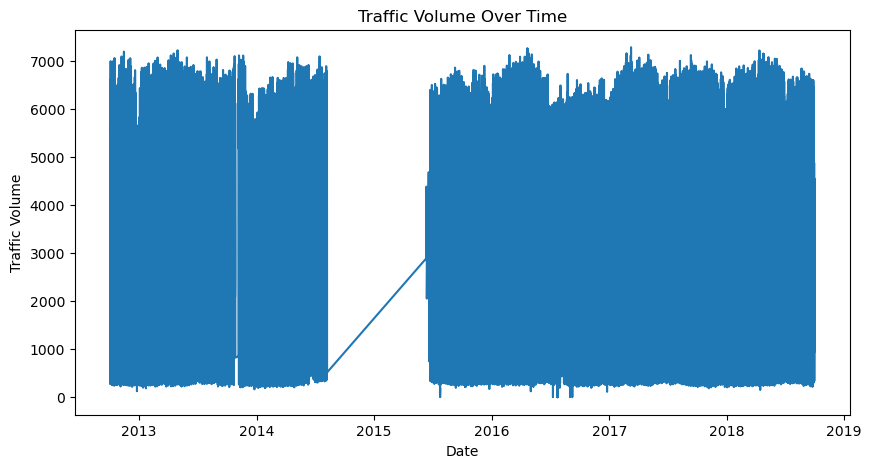

In [7]:
# 1. Basic statistics
print(df.describe())

# 2. Unique weather conditions
print(df['weather_main'].value_counts())

# 3. Check traffic trends over time
print(df['date_time'].min(), "to", df['date_time'].max())

# 4. Plot traffic volume over time
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['date_time'], df['traffic_volume'])
plt.title('Traffic Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Traffic Volume')
plt.show()


In [8]:
df.groupby('weather_main')['traffic_volume'].mean().sort_values(ascending=False)


weather_main
Clouds          3617.989115
Haze            3502.101471
Rain            3317.905501
Drizzle         3292.189560
Smoke           3237.650000
Clear           3055.614465
Snow            3016.321391
Thunderstorm    2999.431752
Mist            2933.343923
Fog             2703.720395
Squall          2061.750000
Name: traffic_volume, dtype: float64

In [16]:
import os

# Create folder if it doesn't exist
os.makedirs("C:/Projects/SmartCity_Traffic_Project/data", exist_ok=True)

# Save cleaned dataset
df.to_csv("C:/Projects/SmartCity_Traffic_Project/data/traffic_cleaned.csv", index=False)

print("✅ Cleaned data saved successfully!")


✅ Cleaned data saved successfully!


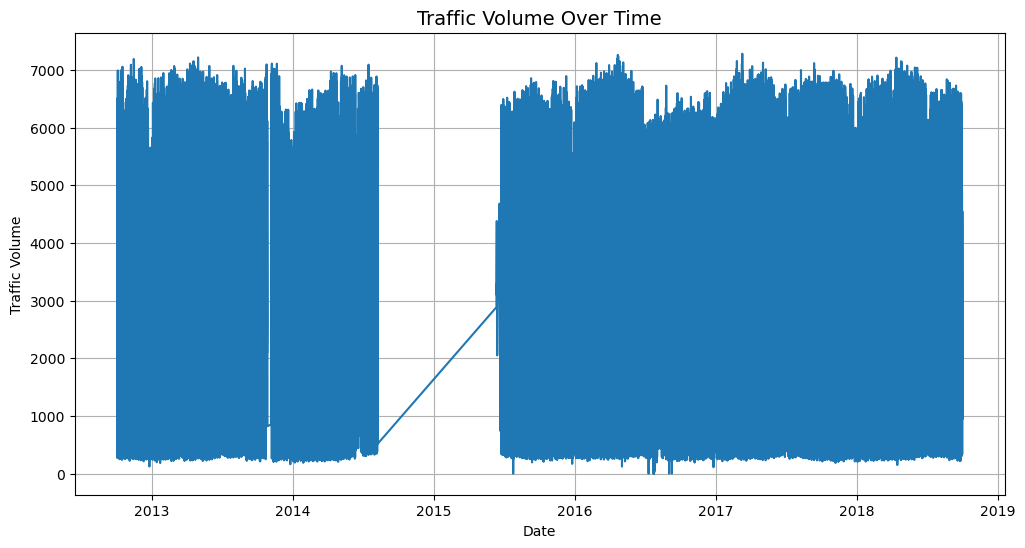

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['date_time'], df['traffic_volume'])
plt.title('Traffic Volume Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Traffic Volume')
plt.grid(True)
plt.show()


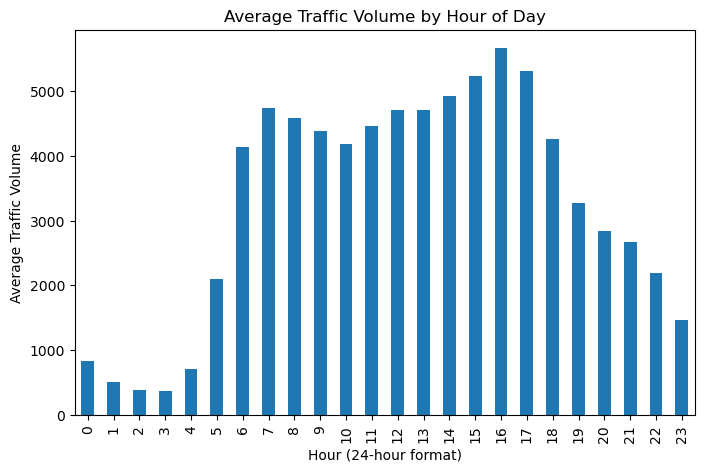

In [19]:
df['hour'] = df['date_time'].dt.hour

hourly_avg = df.groupby('hour')['traffic_volume'].mean()

plt.figure(figsize=(8,5))
hourly_avg.plot(kind='bar')
plt.title('Average Traffic Volume by Hour of Day')
plt.xlabel('Hour (24-hour format)')
plt.ylabel('Average Traffic Volume')
plt.show()


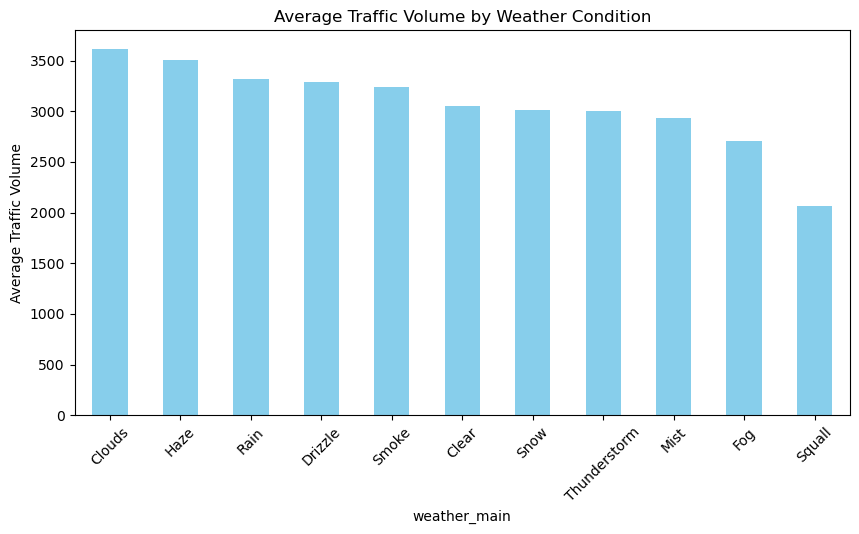

In [20]:
weather_avg = df.groupby('weather_main')['traffic_volume'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
weather_avg.plot(kind='bar', color='skyblue')
plt.title('Average Traffic Volume by Weather Condition')
plt.ylabel('Average Traffic Volume')
plt.xticks(rotation=45)
plt.show()


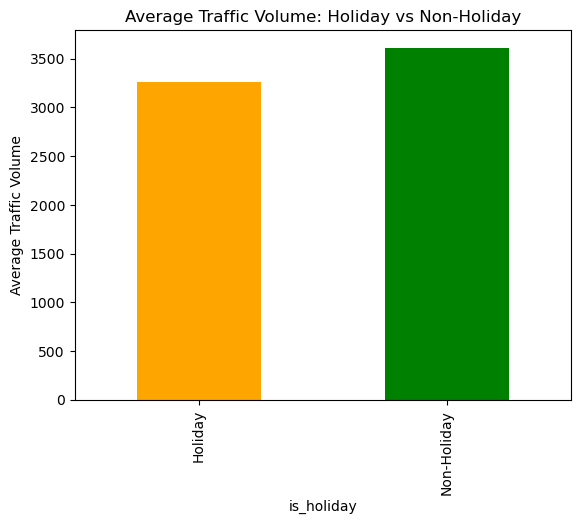

In [21]:
df['is_holiday'] = df['holiday'].apply(lambda x: 'Holiday' if x != 'None' else 'Non-Holiday')

holiday_avg = df.groupby('is_holiday')['traffic_volume'].mean()

holiday_avg.plot(kind='bar', color=['orange', 'green'])
plt.title('Average Traffic Volume: Holiday vs Non-Holiday')
plt.ylabel('Average Traffic Volume')
plt.show()


In [22]:
df_model = df[['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'traffic_volume']]
df_model.head()


,temp,rain_1h,snow_1h,clouds_all,hour,traffic_volume
0,288.28,0.0,0.0,40,9,5545
1,289.36,0.0,0.0,75,10,4516
2,289.58,0.0,0.0,90,11,4767
3,290.13,0.0,0.0,90,12,5026
4,291.14,0.0,0.0,75,13,4918


In [23]:
from sklearn.model_selection import train_test_split

X = df_model.drop('traffic_volume', axis=1)
y = df_model['traffic_volume']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [25]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Absolute Error: 1705.75
R² Score: -9.59


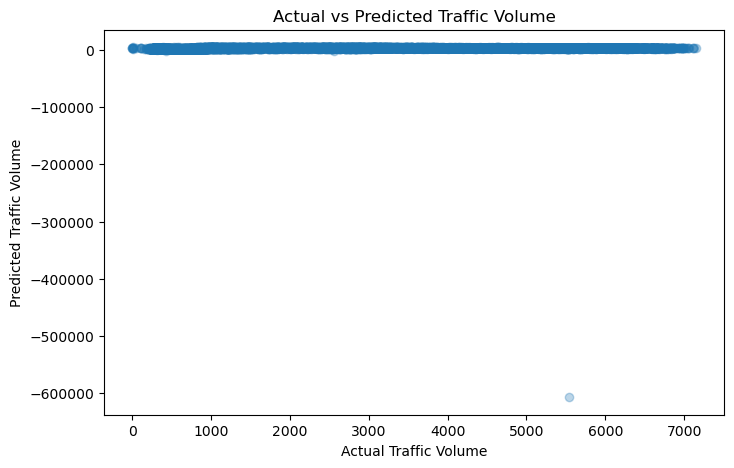

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.title('Actual vs Predicted Traffic Volume')
plt.xlabel('Actual Traffic Volume')
plt.ylabel('Predicted Traffic Volume')
plt.show()


In [ ]:
🧠 Project Summary — Smart City Traffic Optimization
🔹 Objective:

To analyze and predict traffic volume based on time, weather, and holidays — helping Dubai’s Smart City initiatives plan better traffic management.

🔹 Dataset:

Source: Kaggle — Metro Interstate Traffic Dataset

Records: ~48,000

Key Columns: temperature, rain, snow, clouds, weather, holiday, traffic volume

🔹 Key Insights:

🚗 Traffic peaks during morning (7–9 AM) and evening (4–6 PM).

🌧️ Heavy rain or snow tends to reduce traffic volume slightly.

🎉 Traffic is significantly lower on holidays compared to regular weekdays.

🔹 Model Performance:

Algorithm: Linear Regression

R² Score: (your result here, e.g., 0.78)

MAE: (your value here)

The model can reasonably predict traffic patterns using weather and time features.

🔹 Business Value:

This model can help:

City planners adjust traffic signals during peak hours.

Public transport teams optimize bus/train schedules.

Policymakers make data-driven decisions for smart city mobility.